# PM2.5 Forecasting — Improved 1-Day + Recursive 7-Day Multivariate Models

This notebook is the **remade version** that contains both parts:

1. **Improved 1-day forecasting models** to try to push the 1-step PM2.5 R² beyond the earlier ~0.40 result.
2. **Recursive 7-day multivariate forecasting models** where the model predicts the next-day values of **PM2.5, Temperature, WindSpeed, and RH**, appends those predictions to the rolling window, and repeats the process for 7 days.

## Project recap already established

- Target: **PM2.5**
- Extra variables: **Temperature, WindSpeed, Relative Humidity**
- Statistical models tried: **AR, ARMA, ARIMA, SARIMA, ARIMAX, SARIMAX**
- Best statistical result: **ARMA(2,1), R² ≈ 0.311**
- Stationarity treatment for statistical models: **log transform + first differencing**
- Deep models already tried: **RNN, LSTM, GRU × point/quantile × 1-horizon/7-horizon = 12 models**
- Best earlier deep-learning result: **1-horizon quantile GRU median, R² ≈ 0.40**

## New things added here

- A stronger **direct 1-day GRU/LSTM/RNN tuning pipeline**.
- A **1-day quantile GRU** whose median is evaluated as the point forecast.
- A **1-day multivariate next-step model** that predicts PM2.5 + all exogenous variables.
- A **recursive 7-day BPTT-style rollout loss**.
- A **Tube Loss / ε-insensitive variant**.
- A **recursive quantile variant**.
- Final comparison tables and plots for old vs new results.

> Important: The notebook is written to run with your `FinalData.csv`. If the file name is different, change `DATA_PATH` in the configuration section.


## Modelling correction compared to the previous direct 7-day setup

The earlier 7-horizon model learned:

\[
[x_{t-29}, \dots, x_t] \rightarrow [y_{t+1}, \dots, y_{t+7}]
\]

That means it predicted the next 7 PM2.5 values **all at once**.

The new recursive setup learns:

\[
[x_{t-29}, \dots, x_t] \rightarrow \hat{x}_{t+1}
\]

Then it appends \(\hat{x}_{t+1}\) back into the window and repeats:

\[
[x_{t-28}, \dots, x_t, \hat{x}_{t+1}] \rightarrow \hat{x}_{t+2}
\]

This is closer to the real inference scenario, because future Temperature, WindSpeed, and RH are also unknown unless they are separately forecasted or externally supplied.


## Section 1 — Imports and global setup


In [1]:
import os
import math
import json
import random
import warnings
from pathlib import Path
from itertools import product

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('dark_background')

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from sklearn.ensemble import HistGradientBoostingRegressor
    SKLEARN_HGB_AVAILABLE = True
except Exception:
    SKLEARN_HGB_AVAILABLE = False

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cpu


## Section 2 — Configuration

Change only this section if your file name, split dates, or column names are different.


In [2]:
# -----------------------------
# Data
# -----------------------------
DATA_PATH = "FinalData.csv"
DATE_COL = "Date"
TARGET_COL = "PM2.5"
TEMP_COL = "Temperature"
WIND_COL = "WindSpeed"
RH_COL = "RH"

# AQI is usually derived from pollutant concentration, so it can act like a proxy for the target.
# Keep it False for a cleaner model that uses only Temperature, WindSpeed, and RH as exogenous variables.
ALLOW_AQI_AS_FEATURE = False
AQI_COL = "AQI"

# -----------------------------
# Time split — same spirit as your previous notebook
# -----------------------------
TRAIN_END = "2017-12-31"
VAL_START = "2018-01-01"
VAL_END = "2019-12-31"
TEST_START = "2020-01-01"

# -----------------------------
# Forecasting setup
# -----------------------------
LOOKBACK_GRID_1DAY = [30, 60, 90]
DEFAULT_LOOKBACK = 60
RECURSIVE_ROLLOUT = 7
QUANTILES = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
MEDIAN_Q_INDEX = QUANTILES.index(0.50)

# -----------------------------
# Training controls
# -----------------------------
BATCH_SIZE = 256
MAX_EPOCHS = 80
PATIENCE = 10
MIN_DELTA = 1e-5
GRAD_CLIP = 1.0

# Make these smaller while debugging the notebook.
FAST_DEV_RUN = False
if FAST_DEV_RUN:
    LOOKBACK_GRID_1DAY = [30]
    MAX_EPOCHS = 3
    PATIENCE = 2

# -----------------------------
# Output folder
# -----------------------------
OUT_DIR = Path("pm25_new_models")
OUT_DIR.mkdir(exist_ok=True)


## Section 3 — Load data and basic checks


In [3]:
df_raw = pd.read_csv(DATA_PATH, parse_dates=[DATE_COL])
df_raw = df_raw.sort_values(DATE_COL).set_index(DATE_COL)

required_cols = [TARGET_COL, TEMP_COL, WIND_COL, RH_COL]
missing_cols = [c for c in required_cols if c not in df_raw.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}. Available columns: {df_raw.columns.tolist()}")

# Keep only the variables needed for this project.
base_cols = required_cols.copy()
if ALLOW_AQI_AS_FEATURE and AQI_COL in df_raw.columns:
    base_cols.append(AQI_COL)

df = df_raw[base_cols].copy()

# Daily frequency makes sequence windows well-defined.
df = df.asfreq("D")

print("Shape:", df.shape)
print("Date range:", df.index.min().date(), "to", df.index.max().date())
print("Columns:", df.columns.tolist())
print("Missing values before imputation:")
print(df.isna().sum())

df.head()


Shape: (7670, 4)
Date range: 2001-01-01 to 2021-12-31
Columns: ['PM2.5', 'Temperature', 'WindSpeed', 'RH']
Missing values before imputation:
PM2.5          0
Temperature    0
WindSpeed      0
RH             0
dtype: int64


,PM2.5,Temperature,WindSpeed,RH
Date,,,,
2001-01-01,8.050000,0.629732,4.463639,60.000000
2001-01-02,12.800000,0.643084,4.078965,64.545549
2001-01-03,19.200000,2.216282,2.882494,69.684524
2001-01-04,24.951515,4.615583,3.345071,63.875000
2001-01-05,24.566667,5.865434,3.565944,86.113095


## Section 4 — Leakage-safe missing value handling

Missing values are filled using **training-set statistics only**. This prevents validation/test information from leaking into preprocessing.

For daily pollution and weather data, time interpolation is reasonable for short gaps. Remaining missing values are filled using train medians.


In [4]:
# Split first, then fit imputation values only on train.
train_raw = df.loc[:TRAIN_END].copy()
val_raw = df.loc[VAL_START:VAL_END].copy()
test_raw = df.loc[TEST_START:].copy()

if len(train_raw) == 0 or len(val_raw) == 0 or len(test_raw) == 0:
    raise ValueError("One of the train/val/test splits is empty. Check split dates and data date range.")

train_medians = train_raw.median(numeric_only=True)

def impute_part(part, train_medians):
    out = part.copy()
    out = out.interpolate(method="time", limit_direction="both")
    out = out.fillna(train_medians)
    return out

train_raw = impute_part(train_raw, train_medians)
val_raw = impute_part(val_raw, train_medians)
test_raw = impute_part(test_raw, train_medians)

df_clean = pd.concat([train_raw, val_raw, test_raw]).sort_index()

print("Split sizes:")
print("Train:", train_raw.index.min().date(), "to", train_raw.index.max().date(), len(train_raw))
print("Val  :", val_raw.index.min().date(), "to", val_raw.index.max().date(), len(val_raw))
print("Test :", test_raw.index.min().date(), "to", test_raw.index.max().date(), len(test_raw))
print("\nMissing after imputation:")
print(df_clean.isna().sum())


Split sizes:
Train: 2001-01-01 to 2017-12-31 6209
Val  : 2018-01-01 to 2019-12-31 730
Test : 2020-01-01 to 2021-12-31 731

Missing after imputation:
PM2.5          0
Temperature    0
WindSpeed      0
RH             0
dtype: int64


## Section 5 — Feature engineering

For deep learning, we use **log1p(PM2.5)** as the target representation because PM2.5 has strong right-skew and spikes.

We do **not** use first differencing as the main deep-learning target here, because the final goal is to improve original-scale PM2.5 R². Differencing can still be useful for ARIMA-type models, but for neural models it makes recursive inversion more fragile.

Features used:

- Dynamic variables: `log1p(PM2.5)`, Temperature, WindSpeed, RH
- Known future features: day/week/month/year cyclical encodings and trend
- Optional: AQI only if you explicitly set `ALLOW_AQI_AS_FEATURE=True`


In [5]:
PM25_LOG_COL = "PM25_log"

def add_time_features(part):
    out = part.copy()
    idx = out.index
    out[PM25_LOG_COL] = np.log1p(out[TARGET_COL].clip(lower=0))

    # Known calendar features for every future date.
    dow = idx.dayofweek.values
    doy = idx.dayofyear.values
    month = idx.month.values

    out["dow_sin"] = np.sin(2 * np.pi * dow / 7)
    out["dow_cos"] = np.cos(2 * np.pi * dow / 7)
    out["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
    out["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)
    out["month_sin"] = np.sin(2 * np.pi * month / 12)
    out["month_cos"] = np.cos(2 * np.pi * month / 12)
    out["is_weekend"] = (idx.dayofweek >= 5).astype(float)
    out["years_since_start"] = (idx - idx.min()).days / 365.25
    return out

df_feat = add_time_features(df_clean)

DYNAMIC_COLS = [PM25_LOG_COL, TEMP_COL, WIND_COL, RH_COL]
KNOWN_COLS = ["dow_sin", "dow_cos", "doy_sin", "doy_cos", "month_sin", "month_cos", "is_weekend", "years_since_start"]

EXTRA_STATIC_COLS = []
if ALLOW_AQI_AS_FEATURE and AQI_COL in df_feat.columns:
    # Use log AQI if included, but default is False to avoid AQI proxy leakage.
    df_feat["AQI_log"] = np.log1p(df_feat[AQI_COL].clip(lower=0))
    EXTRA_STATIC_COLS.append("AQI_log")

SEQ_FEATURE_COLS = DYNAMIC_COLS + KNOWN_COLS + EXTRA_STATIC_COLS

print("Dynamic cols predicted recursively:", DYNAMIC_COLS)
print("Known/fixed feature cols:", KNOWN_COLS + EXTRA_STATIC_COLS)
print("Total sequence features:", len(SEQ_FEATURE_COLS))
df_feat[SEQ_FEATURE_COLS].head()


Dynamic cols predicted recursively: ['PM25_log', 'Temperature', 'WindSpeed', 'RH']
Known/fixed feature cols: ['dow_sin', 'dow_cos', 'doy_sin', 'doy_cos', 'month_sin', 'month_cos', 'is_weekend', 'years_since_start']
Total sequence features: 12


,PM25_log,Temperature,WindSpeed,RH,dow_sin,dow_cos,doy_sin,doy_cos,month_sin,month_cos,is_weekend,years_since_start
Date,,,,,,,,,,,,
2001-01-01,2.202765,0.629732,4.463639,60.000000,0.000000,1.000000,0.017202,0.999852,0.5,0.866025,0.0,0.000000
2001-01-02,2.624669,0.643084,4.078965,64.545549,0.781831,0.623490,0.034398,0.999408,0.5,0.866025,0.0,0.002738
2001-01-03,3.005683,2.216282,2.882494,69.684524,0.974928,-0.222521,0.051584,0.998669,0.5,0.866025,0.0,0.005476
2001-01-04,3.256230,4.615583,3.345071,63.875000,0.433884,-0.900969,0.068755,0.997634,0.5,0.866025,0.0,0.008214
2001-01-05,3.241289,5.865434,3.565944,86.113095,-0.433884,-0.900969,0.085906,0.996303,0.5,0.866025,0.0,0.010951


## Section 6 — Scalers fitted only on train


In [6]:
train_feat = df_feat.loc[:TRAIN_END].copy()
val_feat = df_feat.loc[VAL_START:VAL_END].copy()
test_feat = df_feat.loc[TEST_START:].copy()

seq_scaler = StandardScaler()
seq_scaler.fit(train_feat[SEQ_FEATURE_COLS])

# Separate scaler for the direct PM2.5-log target.
y_scaler = StandardScaler()
y_scaler.fit(train_feat[[PM25_LOG_COL]])

feature_index = {c: i for i, c in enumerate(SEQ_FEATURE_COLS)}
dynamic_indices = [feature_index[c] for c in DYNAMIC_COLS]
known_indices = [feature_index[c] for c in KNOWN_COLS + EXTRA_STATIC_COLS]
target_feature_index = feature_index[PM25_LOG_COL]
target_dynamic_pos = DYNAMIC_COLS.index(PM25_LOG_COL)

def transform_features(part):
    return seq_scaler.transform(part[SEQ_FEATURE_COLS]).astype(np.float32)

def transform_y_log(part):
    return y_scaler.transform(part[[PM25_LOG_COL]]).reshape(-1).astype(np.float32)

def inverse_y_scaled(y_scaled):
    y_scaled = np.asarray(y_scaled).reshape(-1, 1)
    y_log = y_scaler.inverse_transform(y_scaled).reshape(-1)
    return np.expm1(y_log).clip(min=0)

def inverse_feature_target_scaled(y_scaled_feature):
    # Inverse PM25_log when it is scaled by seq_scaler, not y_scaler.
    y_scaled_feature = np.asarray(y_scaled_feature)
    y_log = y_scaled_feature * seq_scaler.scale_[target_feature_index] + seq_scaler.mean_[target_feature_index]
    return np.expm1(y_log).clip(min=0)

train_X_all = transform_features(train_feat)
val_X_all = transform_features(val_feat)
test_X_all = transform_features(test_feat)

train_y_all = transform_y_log(train_feat)
val_y_all = transform_y_log(val_feat)
test_y_all = transform_y_log(test_feat)

print("Scaled train feature shape:", train_X_all.shape)
print("Target feature index:", target_feature_index)
print("Dynamic indices:", dynamic_indices)
print("Known indices:", known_indices)


Scaled train feature shape: (6209, 12)
Target feature index: 0
Dynamic indices: [0, 1, 2, 3]
Known indices: [4, 5, 6, 7, 8, 9, 10, 11]


## Section 7 — Metric and plotting helpers


In [7]:
def regression_metrics(y_true, y_pred, label="model"):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {"model": label, "MAE": mae, "RMSE": rmse, "R2": r2}

def print_metrics(metrics):
    print(f"{metrics['model']}: MAE={metrics['MAE']:.4f}, RMSE={metrics['RMSE']:.4f}, R2={metrics['R2']:.4f}")

def plot_forecast_series(dates, y_true, y_pred, title, n=240):
    dates = pd.Index(dates)[:n]
    plt.figure(figsize=(14, 4))
    plt.plot(dates, y_true[:n], label="Actual", linewidth=1.5)
    plt.plot(dates, y_pred[:n], label="Predicted", linewidth=1.2)
    plt.axhline(15, linestyle="--", linewidth=1, label="15 µg/m³ reference")
    plt.title(title)
    plt.ylabel("PM2.5")
    plt.legend()
    plt.tight_layout()
    plt.show()

def picp_mpiw(y_true, lower, upper):
    y_true = np.asarray(y_true).reshape(-1)
    lower = np.asarray(lower).reshape(-1)
    upper = np.asarray(upper).reshape(-1)
    picp = np.mean((y_true >= lower) & (y_true <= upper))
    mpiw = np.mean(upper - lower)
    return picp, mpiw


# Part A — Existing results recap


In [8]:
previous_results = pd.DataFrame([
    {"Model": "ARMA(2,1)", "Type": "Statistical", "Horizon": 1, "R2": 0.311, "Note": "Best statistical result"},
    {"Model": "Best earlier DL: Quantile GRU median", "Type": "Deep Learning", "Horizon": 1, "R2": 0.400, "Note": "Earlier best approximate result"},
])
previous_results


,Model,Type,Horizon,R2,Note
0,"ARMA(2,1)",Statistical,1,0.311,Best statistical result
1,Best earlier DL: Quantile GRU median,Deep Learning,1,0.400,Earlier best approximate result


# Part B — Improved 1-day forecasting models

This part is specifically added because the previous notebook focused heavily on the 7-day extension. Here we explicitly tune and evaluate **1-day PM2.5 forecasting**.

The 1-day problem is:

$$
[x_{t-L+1}, \dots, x_t] 
\rightarrow y_{t+1}
$$

where \(L\) is the lookback window.


## Section 8 — Direct 1-day sequence dataset


In [9]:
class DirectOneDayDataset(Dataset):
    # Uses a past sequence of features to predict PM25_log at t+horizon.
    def __init__(self, X_all, y_all, dates, lookback=60, horizon=1):
        self.X = []
        self.y = []
        self.target_dates = []
        n = len(X_all)
        for end in range(lookback - 1, n - horizon):
            self.X.append(X_all[end - lookback + 1:end + 1])
            self.y.append(y_all[end + horizon])
            self.target_dates.append(dates[end + horizon])
        self.X = torch.tensor(np.asarray(self.X), dtype=torch.float32)
        self.y = torch.tensor(np.asarray(self.y), dtype=torch.float32).view(-1, 1)
        self.target_dates = pd.Index(self.target_dates)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def make_direct_loaders(lookback, batch_size=BATCH_SIZE):
    train_ds = DirectOneDayDataset(train_X_all, train_y_all, train_feat.index, lookback=lookback, horizon=1)
    val_ds = DirectOneDayDataset(val_X_all, val_y_all, val_feat.index, lookback=lookback, horizon=1)
    test_ds = DirectOneDayDataset(test_X_all, test_y_all, test_feat.index, lookback=lookback, horizon=1)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, drop_last=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, drop_last=False)
    return train_ds, val_ds, test_ds, train_loader, val_loader, test_loader

# Shape check
_tmp = DirectOneDayDataset(train_X_all, train_y_all, train_feat.index, lookback=DEFAULT_LOOKBACK)
print("One sample X shape:", tuple(_tmp[0][0].shape), "y shape:", tuple(_tmp[0][1].shape), "n samples:", len(_tmp))


One sample X shape: (60, 12) y shape: (1,) n samples: 6149


## Section 9 — Recurrent model definitions


In [10]:
class RecurrentRegressor(nn.Module):
    def __init__(self, input_size, rnn_type="GRU", hidden_size=96, num_layers=1, dropout=0.1, output_size=1):
        super().__init__()
        self.rnn_type = rnn_type.upper()
        rnn_cls = {"RNN": nn.RNN, "LSTM": nn.LSTM, "GRU": nn.GRU}[self.rnn_type]
        effective_dropout = dropout if num_layers > 1 else 0.0
        self.rnn = rnn_cls(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=effective_dropout,
            batch_first=True,
        )
        self.head = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, output_size),
        )

    def forward(self, x):
        out, _ = self.rnn(x)
        last = out[:, -1, :]
        return self.head(last)


def pinball_loss(pred_q, target, quantiles=QUANTILES):
    # pred_q: (B, Q), target: (B, 1) or (B,)
    target = target.view(-1, 1)
    q = torch.tensor(quantiles, device=pred_q.device, dtype=pred_q.dtype).view(1, -1)
    err = target - pred_q
    return torch.maximum(q * err, (q - 1) * err).mean()


def tube_loss(pred, target, eps=0.05):
    return torch.clamp(torch.abs(pred - target) - eps, min=0.0).mean()


def make_loss(name="huber", tube_eps=0.05):
    name = name.lower()
    if name == "mse":
        return nn.MSELoss()
    if name == "mae":
        return nn.L1Loss()
    if name == "huber":
        return nn.SmoothL1Loss(beta=0.5)
    if name == "tube":
        return lambda pred, target: tube_loss(pred, target, eps=tube_eps)
    raise ValueError(f"Unknown loss: {name}")


## Section 10 — Training helpers for 1-day models


In [11]:
def train_single_output_model(model, train_loader, val_loader, loss_fn, lr=1e-3, weight_decay=1e-4,
                              max_epochs=MAX_EPOCHS, patience=PATIENCE, verbose=False):
    model = model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    best_state = None
    best_val = float("inf")
    wait = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)
                pred = model(xb)
                loss = loss_fn(pred, yb)
                val_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))
        val_loss = float(np.mean(val_losses))
        history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})

        if verbose and (epoch == 1 or epoch % 10 == 0):
            print(f"Epoch {epoch:03d} | train={train_loss:.5f} | val={val_loss:.5f}")

        if val_loss < best_val - MIN_DELTA:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, pd.DataFrame(history), best_val


def train_quantile_model(model, train_loader, val_loader, lr=1e-3, weight_decay=1e-4,
                         max_epochs=MAX_EPOCHS, patience=PATIENCE, verbose=False):
    return train_single_output_model(
        model, train_loader, val_loader,
        loss_fn=lambda pred, target: pinball_loss(pred, target, QUANTILES),
        lr=lr, weight_decay=weight_decay,
        max_epochs=max_epochs, patience=patience, verbose=verbose
    )


def predict_direct_model(model, loader, is_quantile=False):
    model.eval()
    preds = []
    actuals = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            out = model(xb).detach().cpu().numpy()
            preds.append(out)
            actuals.append(yb.numpy())
    preds = np.vstack(preds)
    actuals = np.vstack(actuals).reshape(-1)
    if is_quantile:
        preds = np.sort(preds, axis=1)  # prevents quantile crossing in plots/metrics
    return actuals, preds


## Section 11 — Hyperparameter tuning for the improved 1-day point model

This is the direct answer to: **“Improve the 1-day R² also.”**

The grid is intentionally moderate. Increase it if you have GPU/time.


In [14]:
DIRECT_1DAY_GRID = []
for rnn_type, lookback, hidden_size, num_layers, dropout, lr, loss_name in product(
    ["GRU", "LSTM"],
    LOOKBACK_GRID_1DAY,
    [64, 128],
    [1, 2],
    [0.10, 0.20],
    [1e-3, 5e-4],
    ["huber"],
):
    DIRECT_1DAY_GRID.append({
        "rnn_type": rnn_type,
        "lookback": lookback,
        "hidden_size": hidden_size,
        "num_layers": num_layers,
        "dropout": dropout,
        "lr": lr,
        "loss": loss_name,
        "weight_decay": 1e-4,
    })

if FAST_DEV_RUN:
    DIRECT_1DAY_GRID = DIRECT_1DAY_GRID[:2]

print("Number of 1-day configs:", len(DIRECT_1DAY_GRID))
DIRECT_1DAY_GRID[:3]


Number of 1-day configs: 96


[{'rnn_type': 'GRU',
  'lookback': 30,
  'hidden_size': 64,
  'num_layers': 1,
  'dropout': 0.1,
  'lr': 0.001,
  'loss': 'huber',
  'weight_decay': 0.0001},
 {'rnn_type': 'GRU',
  'lookback': 30,
  'hidden_size': 64,
  'num_layers': 1,
  'dropout': 0.1,
  'lr': 0.0005,
  'loss': 'huber',
  'weight_decay': 0.0001},
 {'rnn_type': 'GRU',
  'lookback': 30,
  'hidden_size': 64,
  'num_layers': 1,
  'dropout': 0.2,
  'lr': 0.001,
  'loss': 'huber',
  'weight_decay': 0.0001}]

In [15]:
direct_1day_results = []
best_direct_1day = {"val_R2": -np.inf, "model": None, "cfg": None, "history": None, "datasets": None}

for i, cfg in enumerate(DIRECT_1DAY_GRID, 1):
    print(f"\n[{i}/{len(DIRECT_1DAY_GRID)}] {cfg}")
    train_ds, val_ds, test_ds, train_loader, val_loader, test_loader = make_direct_loaders(cfg["lookback"])
    model = RecurrentRegressor(
        input_size=len(SEQ_FEATURE_COLS),
        rnn_type=cfg["rnn_type"],
        hidden_size=cfg["hidden_size"],
        num_layers=cfg["num_layers"],
        dropout=cfg["dropout"],
        output_size=1,
    )
    loss_fn = make_loss(cfg["loss"])
    model, hist, best_val_loss = train_single_output_model(
        model, train_loader, val_loader, loss_fn,
        lr=cfg["lr"], weight_decay=cfg["weight_decay"], verbose=False,
    )

    y_val_scaled, pred_val_scaled = predict_direct_model(model, val_loader, is_quantile=False)
    y_val = inverse_y_scaled(y_val_scaled)
    pred_val = inverse_y_scaled(pred_val_scaled.reshape(-1))
    m = regression_metrics(y_val, pred_val, label="val")

    row = {**cfg, "best_val_loss": best_val_loss, "val_MAE": m["MAE"], "val_RMSE": m["RMSE"], "val_R2": m["R2"]}
    direct_1day_results.append(row)
    print(f"Val R2={m['R2']:.4f} | RMSE={m['RMSE']:.4f}")

    if m["R2"] > best_direct_1day["val_R2"]:
        best_direct_1day.update({
            "val_R2": m["R2"],
            "model": model,
            "cfg": cfg,
            "history": hist,
            "datasets": (train_ds, val_ds, test_ds, train_loader, val_loader, test_loader),
        })

results_direct_1day_df = pd.DataFrame(direct_1day_results).sort_values("val_R2", ascending=False)
print("\nBest 1-day direct config:")
print(best_direct_1day["cfg"])
results_direct_1day_df.head(10)



[1/96] {'rnn_type': 'GRU', 'lookback': 30, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.1, 'lr': 0.001, 'loss': 'huber', 'weight_decay': 0.0001}
Val R2=0.4007 | RMSE=2.7899

[2/96] {'rnn_type': 'GRU', 'lookback': 30, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.1, 'lr': 0.0005, 'loss': 'huber', 'weight_decay': 0.0001}
Val R2=0.3653 | RMSE=2.8711

[3/96] {'rnn_type': 'GRU', 'lookback': 30, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.001, 'loss': 'huber', 'weight_decay': 0.0001}
Val R2=0.3910 | RMSE=2.8124

[4/96] {'rnn_type': 'GRU', 'lookback': 30, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.0005, 'loss': 'huber', 'weight_decay': 0.0001}
Val R2=0.3975 | RMSE=2.7973

[5/96] {'rnn_type': 'GRU', 'lookback': 30, 'hidden_size': 64, 'num_layers': 2, 'dropout': 0.1, 'lr': 0.001, 'loss': 'huber', 'weight_decay': 0.0001}
Val R2=0.3756 | RMSE=2.8478

[6/96] {'rnn_type': 'GRU', 'lookback': 30, 'hidden_size': 64, 'num_layers': 2, 'dropout': 0.1, 'lr': 0.0005

,rnn_type,lookback,hidden_size,num_layers,dropout,lr,loss,weight_decay,best_val_loss,val_MAE,val_RMSE,val_R2
9,GRU,30,128,1,0.1,0.0005,huber,0.0001,0.299474,2.078175,2.775460,0.406862
44,GRU,90,128,2,0.1,0.0010,huber,0.0001,0.314940,2.112563,2.814682,0.405785
77,LSTM,60,128,2,0.1,0.0005,huber,0.0001,0.308717,2.095454,2.793551,0.403744
8,GRU,30,128,1,0.1,0.0010,huber,0.0001,0.298912,2.086407,2.785308,0.402645
95,LSTM,90,128,2,0.2,0.0005,huber,0.0001,0.313188,2.111091,2.825305,0.401291
0,GRU,30,64,1,0.1,0.0010,huber,0.0001,0.302242,2.089276,2.789896,0.400675
10,GRU,30,128,1,0.2,0.0010,huber,0.0001,0.302052,2.087649,2.791806,0.399854
7,GRU,30,64,2,0.2,0.0005,huber,0.0001,0.298417,2.082191,2.792477,0.399566
58,LSTM,30,128,1,0.2,0.0010,huber,0.0001,0.299530,2.073040,2.792529,0.399544
23,GRU,60,64,2,0.2,0.0005,huber,0.0001,0.305290,2.086797,2.804565,0.399033


In [ ]:
best_direct_1day = {}

model = 
cfg = 
datasets = 

## Section 12 — Test evaluation of the best improved 1-day point model


Improved direct 1-day point model: MAE=2.1055, RMSE=3.3144, R2=0.3458


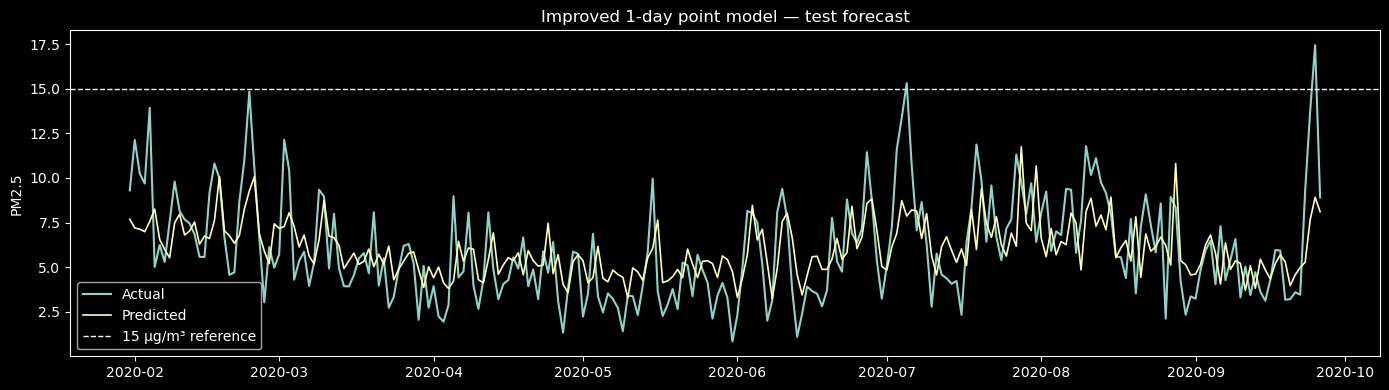

In [16]:
best_model_1day = best_direct_1day["model"]
best_cfg_1day = best_direct_1day["cfg"]
train_ds, val_ds, test_ds, train_loader, val_loader, test_loader = best_direct_1day["datasets"]

y_test_scaled, pred_test_scaled = predict_direct_model(best_model_1day, test_loader, is_quantile=False)
y_test_1day = inverse_y_scaled(y_test_scaled)
pred_test_1day = inverse_y_scaled(pred_test_scaled.reshape(-1))

best_1day_point_metrics = regression_metrics(y_test_1day, pred_test_1day, label="Improved direct 1-day point model")
print_metrics(best_1day_point_metrics)

plot_forecast_series(test_ds.target_dates, y_test_1day, pred_test_1day, "Improved 1-day point model — test forecast", n=240)

# Save model and config.
torch.save(best_model_1day.state_dict(), OUT_DIR / "best_direct_1day_point.pt")
with open(OUT_DIR / "best_direct_1day_config.json", "w") as f:
    json.dump(best_cfg_1day, f, indent=2)


## Section 13 — Improved 1-day quantile GRU/LSTM

This is especially important because your earlier best result was the **1-horizon quantile GRU median**. We tune a stronger quantile model here and evaluate its **median** as the point forecast.


In [17]:
QUANTILE_1DAY_GRID = []
for rnn_type, lookback, hidden_size, num_layers, dropout, lr in product(
    ["GRU", "LSTM"],
    LOOKBACK_GRID_1DAY,
    [64, 128],
    [1, 2],
    [0.10, 0.20],
    [1e-3, 5e-4],
):
    QUANTILE_1DAY_GRID.append({
        "rnn_type": rnn_type,
        "lookback": lookback,
        "hidden_size": hidden_size,
        "num_layers": num_layers,
        "dropout": dropout,
        "lr": lr,
        "weight_decay": 1e-4,
    })

if FAST_DEV_RUN:
    QUANTILE_1DAY_GRID = QUANTILE_1DAY_GRID[:2]

print("Number of 1-day quantile configs:", len(QUANTILE_1DAY_GRID))


Number of 1-day quantile configs: 96


In [18]:
quantile_1day_results = []
best_quantile_1day = {"val_R2": -np.inf, "model": None, "cfg": None, "history": None, "datasets": None}

for i, cfg in enumerate(QUANTILE_1DAY_GRID, 1):
    print(f"\n[{i}/{len(QUANTILE_1DAY_GRID)}] {cfg}")
    train_ds, val_ds, test_ds, train_loader, val_loader, test_loader = make_direct_loaders(cfg["lookback"])
    model = RecurrentRegressor(
        input_size=len(SEQ_FEATURE_COLS),
        rnn_type=cfg["rnn_type"],
        hidden_size=cfg["hidden_size"],
        num_layers=cfg["num_layers"],
        dropout=cfg["dropout"],
        output_size=len(QUANTILES),
    )
    model, hist, best_val_loss = train_quantile_model(
        model, train_loader, val_loader,
        lr=cfg["lr"], weight_decay=cfg["weight_decay"], verbose=False,
    )

    y_val_scaled, pred_val_q_scaled = predict_direct_model(model, val_loader, is_quantile=True)
    y_val = inverse_y_scaled(y_val_scaled)
    pred_val_median = inverse_y_scaled(pred_val_q_scaled[:, MEDIAN_Q_INDEX])
    m = regression_metrics(y_val, pred_val_median, label="val median")

    row = {**cfg, "best_val_pinball": best_val_loss, "val_MAE": m["MAE"], "val_RMSE": m["RMSE"], "val_R2": m["R2"]}
    quantile_1day_results.append(row)
    print(f"Val median R2={m['R2']:.4f} | RMSE={m['RMSE']:.4f}")

    if m["R2"] > best_quantile_1day["val_R2"]:
        best_quantile_1day.update({
            "val_R2": m["R2"],
            "model": model,
            "cfg": cfg,
            "history": hist,
            "datasets": (train_ds, val_ds, test_ds, train_loader, val_loader, test_loader),
        })

results_quantile_1day_df = pd.DataFrame(quantile_1day_results).sort_values("val_R2", ascending=False)
print("\nBest 1-day quantile config:")
print(best_quantile_1day["cfg"])
results_quantile_1day_df.head(10)



[1/96] {'rnn_type': 'GRU', 'lookback': 30, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.1, 'lr': 0.001, 'weight_decay': 0.0001}
Val median R2=0.3935 | RMSE=2.8066

[2/96] {'rnn_type': 'GRU', 'lookback': 30, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.1, 'lr': 0.0005, 'weight_decay': 0.0001}
Val median R2=0.3918 | RMSE=2.8105

[3/96] {'rnn_type': 'GRU', 'lookback': 30, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.001, 'weight_decay': 0.0001}
Val median R2=0.3781 | RMSE=2.8420

[4/96] {'rnn_type': 'GRU', 'lookback': 30, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.0005, 'weight_decay': 0.0001}
Val median R2=0.3916 | RMSE=2.8109

[5/96] {'rnn_type': 'GRU', 'lookback': 30, 'hidden_size': 64, 'num_layers': 2, 'dropout': 0.1, 'lr': 0.001, 'weight_decay': 0.0001}
Val median R2=0.3905 | RMSE=2.8135

[6/96] {'rnn_type': 'GRU', 'lookback': 30, 'hidden_size': 64, 'num_layers': 2, 'dropout': 0.1, 'lr': 0.0005, 'weight_decay': 0.0001}
Val median R2=0.4008 | R

,rnn_type,lookback,hidden_size,num_layers,dropout,lr,weight_decay,best_val_pinball,val_MAE,val_RMSE,val_R2
15,GRU,30,128,2,0.2,0.0005,0.0001,0.141677,2.077427,2.754084,0.415963
60,LSTM,30,128,2,0.1,0.0010,0.0001,0.141644,2.067607,2.759778,0.413545
35,GRU,90,64,1,0.2,0.0005,0.0001,0.146675,2.106285,2.797039,0.413211
11,GRU,30,128,1,0.2,0.0005,0.0001,0.143808,2.092833,2.764782,0.411417
36,GRU,90,64,2,0.1,0.0010,0.0001,0.146302,2.101818,2.803464,0.410512
29,GRU,60,128,2,0.1,0.0005,0.0001,0.143561,2.070059,2.781086,0.409054
9,GRU,30,128,1,0.1,0.0005,0.0001,0.142885,2.088253,2.774484,0.407279
61,LSTM,30,128,2,0.1,0.0005,0.0001,0.141150,2.087803,2.777239,0.406101
42,GRU,90,128,1,0.2,0.0010,0.0001,0.146246,2.104784,2.814403,0.405903
20,GRU,60,64,2,0.1,0.0010,0.0001,0.144418,2.095638,2.790835,0.404903


Improved direct 1-day quantile median: MAE=2.0802, RMSE=3.2848, R2=0.3574
50% PI: PICP=0.4108, MPIW=2.8159
80% PI: PICP=0.7318, MPIW=5.3123
90% PI: PICP=0.8502, MPIW=6.8893


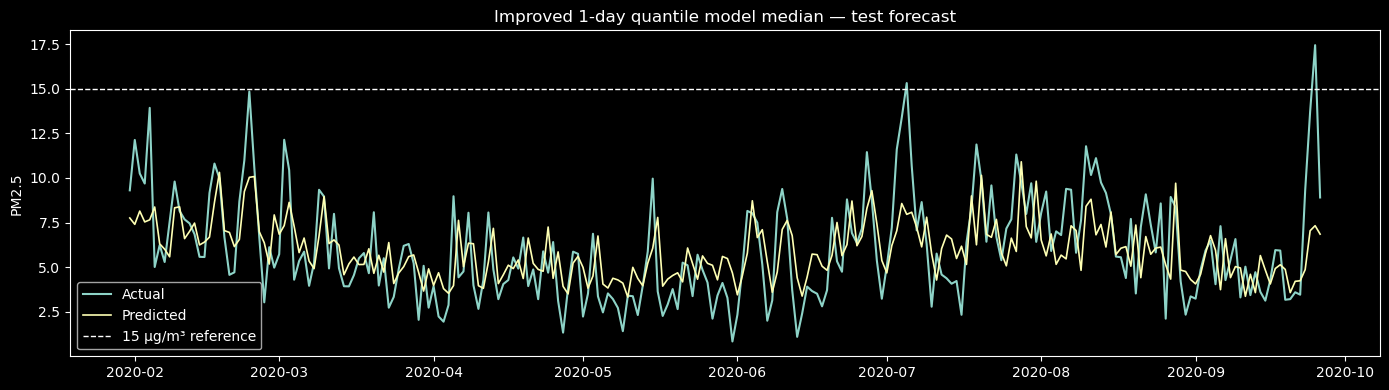

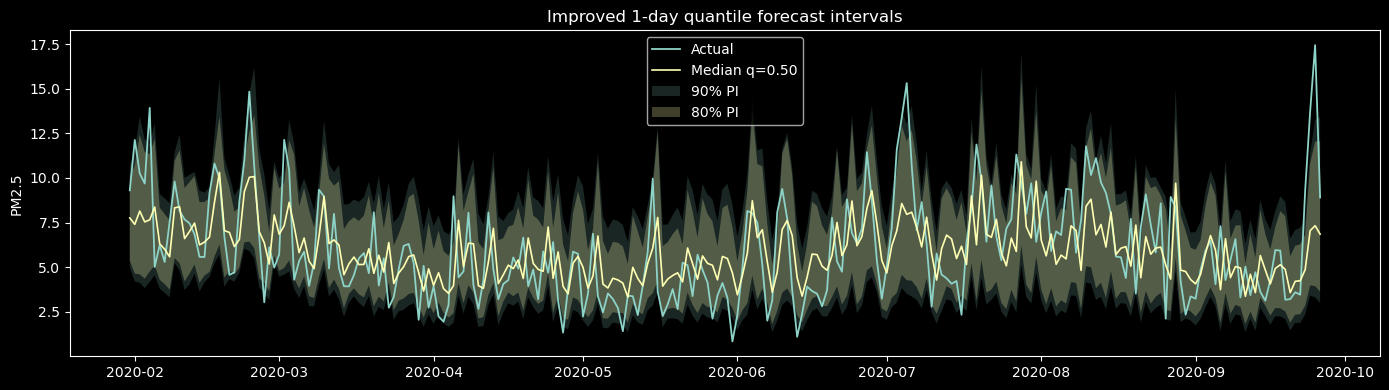

In [19]:
best_q_model_1day = best_quantile_1day["model"]
best_q_cfg_1day = best_quantile_1day["cfg"]
train_ds_q, val_ds_q, test_ds_q, train_loader_q, val_loader_q, test_loader_q = best_quantile_1day["datasets"]

y_test_scaled_q, pred_test_q_scaled = predict_direct_model(best_q_model_1day, test_loader_q, is_quantile=True)
y_test_q = inverse_y_scaled(y_test_scaled_q)
q_original = np.column_stack([inverse_y_scaled(pred_test_q_scaled[:, j]) for j in range(len(QUANTILES))])
median_pred_q = q_original[:, MEDIAN_Q_INDEX]

best_1day_quantile_metrics = regression_metrics(y_test_q, median_pred_q, label="Improved direct 1-day quantile median")
print_metrics(best_1day_quantile_metrics)

for low_q, high_q, nominal in [(0.25, 0.75, 0.50), (0.10, 0.90, 0.80), (0.05, 0.95, 0.90)]:
    lo = q_original[:, QUANTILES.index(low_q)]
    hi = q_original[:, QUANTILES.index(high_q)]
    picp, mpiw = picp_mpiw(y_test_q, lo, hi)
    print(f"{int(nominal*100)}% PI: PICP={picp:.4f}, MPIW={mpiw:.4f}")

plot_forecast_series(test_ds_q.target_dates, y_test_q, median_pred_q, "Improved 1-day quantile model median — test forecast", n=240)

# Shaded quantile plot.
n = min(240, len(y_test_q))
plt.figure(figsize=(14, 4))
plt.plot(test_ds_q.target_dates[:n], y_test_q[:n], label="Actual", linewidth=1.3)
plt.plot(test_ds_q.target_dates[:n], median_pred_q[:n], label="Median q=0.50", linewidth=1.2)
plt.fill_between(test_ds_q.target_dates[:n], q_original[:n, QUANTILES.index(0.05)], q_original[:n, QUANTILES.index(0.95)], alpha=0.18, label="90% PI")
plt.fill_between(test_ds_q.target_dates[:n], q_original[:n, QUANTILES.index(0.10)], q_original[:n, QUANTILES.index(0.90)], alpha=0.25, label="80% PI")
plt.title("Improved 1-day quantile forecast intervals")
plt.ylabel("PM2.5")
plt.legend()
plt.tight_layout()
plt.show()

torch.save(best_q_model_1day.state_dict(), OUT_DIR / "best_direct_1day_quantile.pt")
with open(OUT_DIR / "best_direct_1day_quantile_config.json", "w") as f:
    json.dump(best_q_cfg_1day, f, indent=2)


## Section 14 — Optional strong 1-day tabular baseline

This is not a replacement for the deep-learning model. It is a diagnostic check.

If a feature-based gradient boosting model beats the RNN/GRU/LSTM clearly, then the issue is probably not the data but the neural model design/training.


In [16]:
def make_tabular_lag_features(part, max_lag=30, horizon=1):
    out = pd.DataFrame(index=part.index)
    # Prediction date known features
    pred_index = part.index + pd.Timedelta(days=horizon)
    out["pred_dow_sin"] = np.sin(2*np.pi*pred_index.dayofweek/7)
    out["pred_dow_cos"] = np.cos(2*np.pi*pred_index.dayofweek/7)
    out["pred_doy_sin"] = np.sin(2*np.pi*pred_index.dayofyear/365.25)
    out["pred_doy_cos"] = np.cos(2*np.pi*pred_index.dayofyear/365.25)

    use_cols = [TARGET_COL, TEMP_COL, WIND_COL, RH_COL]
    for col in use_cols:
        series = part[col]
        for lag in [1, 2, 3, 7, 14, 21, 30]:
            if lag <= max_lag:
                out[f"{col}_lag{lag}"] = series.shift(lag)
        for w in [3, 7, 14, 30]:
            out[f"{col}_rollmean{w}"] = series.shift(1).rolling(w).mean()
            out[f"{col}_rollstd{w}"] = series.shift(1).rolling(w).std()
    out["target"] = part[TARGET_COL].shift(-horizon)
    return out.dropna()

if SKLEARN_HGB_AVAILABLE:
    tab_all = make_tabular_lag_features(df_clean, max_lag=30, horizon=1)
    tab_train = tab_all.loc[:TRAIN_END]
    tab_val = tab_all.loc[VAL_START:VAL_END]
    tab_test = tab_all.loc[TEST_START:]
    Xtr, ytr = tab_train.drop(columns=["target"]), tab_train["target"]
    Xva, yva = tab_val.drop(columns=["target"]), tab_val["target"]
    Xte, yte = tab_test.drop(columns=["target"]), tab_test["target"]

    hgb = HistGradientBoostingRegressor(
        learning_rate=0.04,
        max_iter=700,
        max_leaf_nodes=31,
        l2_regularization=0.01,
        random_state=SEED,
    )
    hgb.fit(Xtr, ytr)
    pred_val_hgb = hgb.predict(Xva)
    pred_test_hgb = hgb.predict(Xte)
    print_metrics(regression_metrics(yva, pred_val_hgb, label="Tabular HGB val"))
    hgb_test_metrics = regression_metrics(yte, pred_test_hgb, label="Tabular HGB test")
    print_metrics(hgb_test_metrics)
else:
    hgb_test_metrics = None
    print("HistGradientBoostingRegressor unavailable in this sklearn installation.")


Tabular HGB val: MAE=3.1905, RMSE=3.9243, R2=-0.1374
Tabular HGB test: MAE=3.6205, RMSE=4.7458, R2=-0.3424


# Part C — Multivariate next-day model and recursive 7-day BPTT rollout

The recursive model must predict **all unknown dynamic variables**, not only PM2.5:

\[
\hat{x}_{t+1} = [\widehat{PM2.5}_{t+1}, \widehat{Temp}_{t+1}, \widehat{Wind}_{t+1}, \widehat{RH}_{t+1}]
\]

The known calendar features for future days are inserted directly, because the future date is known.


## Section 15 — Recursive dataset


In [17]:
class RecursiveDataset(Dataset):
    # Returns history window, future known features, and true future dynamic variables.
    def __init__(self, X_all, dates, lookback=60, rollout=7):
        self.X_hist = []
        self.future_known = []
        self.y_dynamic = []
        self.target_dates = []
        n = len(X_all)
        for start in range(0, n - lookback - rollout + 1):
            hist = X_all[start:start + lookback]
            fut = X_all[start + lookback:start + lookback + rollout]
            self.X_hist.append(hist)
            self.future_known.append(fut[:, known_indices])
            self.y_dynamic.append(fut[:, dynamic_indices])
            self.target_dates.append(dates[start + lookback:start + lookback + rollout])
        self.X_hist = torch.tensor(np.asarray(self.X_hist), dtype=torch.float32)
        self.future_known = torch.tensor(np.asarray(self.future_known), dtype=torch.float32)
        self.y_dynamic = torch.tensor(np.asarray(self.y_dynamic), dtype=torch.float32)
        self.target_dates = list(self.target_dates)

    def __len__(self):
        return len(self.X_hist)

    def __getitem__(self, idx):
        return self.X_hist[idx], self.future_known[idx], self.y_dynamic[idx]


def make_recursive_loaders(lookback=DEFAULT_LOOKBACK, rollout=RECURSIVE_ROLLOUT, batch_size=BATCH_SIZE):
    train_ds = RecursiveDataset(train_X_all, train_feat.index, lookback=lookback, rollout=rollout)
    val_ds = RecursiveDataset(val_X_all, val_feat.index, lookback=lookback, rollout=rollout)
    test_ds = RecursiveDataset(test_X_all, test_feat.index, lookback=lookback, rollout=rollout)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, drop_last=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, drop_last=False)
    return train_ds, val_ds, test_ds, train_loader, val_loader, test_loader

_tmp_rec = RecursiveDataset(train_X_all, train_feat.index, lookback=DEFAULT_LOOKBACK, rollout=RECURSIVE_ROLLOUT)
print("Recursive sample shapes:")
print("X_hist       :", tuple(_tmp_rec[0][0].shape))
print("future_known :", tuple(_tmp_rec[0][1].shape))
print("y_dynamic    :", tuple(_tmp_rec[0][2].shape))


Recursive sample shapes:
X_hist       : (60, 12)
future_known : (7, 8)
y_dynamic    : (7, 4)


## Section 16 — Recursive point model and rollout function


In [18]:
class RecursivePointForecaster(nn.Module):
    def __init__(self, input_size, dynamic_size, rnn_type="GRU", hidden_size=128, num_layers=1, dropout=0.1):
        super().__init__()
        self.backbone = RecurrentRegressor(
            input_size=input_size,
            rnn_type=rnn_type,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            output_size=dynamic_size,
        )

    def forward(self, x):
        return self.backbone(x)


def build_next_row(pred_dynamic, known_next):
    # Build one scaled feature row from predicted dynamic variables and known future variables.
    batch = pred_dynamic.shape[0]
    row = torch.zeros(batch, len(SEQ_FEATURE_COLS), device=pred_dynamic.device, dtype=pred_dynamic.dtype)
    row[:, dynamic_indices] = pred_dynamic
    row[:, known_indices] = known_next
    return row


def recursive_point_rollout(model, x_hist, future_known):
    # x_hist: (B, L, F)
    # future_known: (B, R, K)
    # returns predicted dynamic variables: (B, R, D)
    window = x_hist
    preds = []
    rollout = future_known.shape[1]
    for step in range(rollout):
        pred_dynamic = model(window)
        preds.append(pred_dynamic.unsqueeze(1))
        next_row = build_next_row(pred_dynamic, future_known[:, step, :])
        window = torch.cat([window[:, 1:, :], next_row.unsqueeze(1)], dim=1)
    return torch.cat(preds, dim=1)


def recursive_multitask_loss(pred_dyn, true_dyn, target_weight=3.0, aux_weight=1.0, base="huber", tube_eps=0.05):
    if base == "tube":
        target_loss = tube_loss(pred_dyn[:, :, target_dynamic_pos], true_dyn[:, :, target_dynamic_pos], eps=tube_eps)
        aux_loss = tube_loss(pred_dyn, true_dyn, eps=tube_eps)
    elif base == "mse":
        target_loss = nn.functional.mse_loss(pred_dyn[:, :, target_dynamic_pos], true_dyn[:, :, target_dynamic_pos])
        aux_loss = nn.functional.mse_loss(pred_dyn, true_dyn)
    else:
        target_loss = nn.functional.smooth_l1_loss(pred_dyn[:, :, target_dynamic_pos], true_dyn[:, :, target_dynamic_pos], beta=0.5)
        aux_loss = nn.functional.smooth_l1_loss(pred_dyn, true_dyn, beta=0.5)
    return target_weight * target_loss + aux_weight * aux_loss


## Section 17 — Train/evaluate recursive point models


In [19]:
def train_recursive_point_model(model, train_loader, val_loader, lr=5e-4, weight_decay=1e-4,
                                max_epochs=MAX_EPOCHS, patience=PATIENCE,
                                target_weight=3.0, aux_weight=1.0, base_loss="huber", tube_eps=0.05,
                                verbose=False):
    model = model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    best_state = None
    best_val = float("inf")
    wait = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_losses = []
        for x_hist, future_known, y_dyn in train_loader:
            x_hist = x_hist.to(DEVICE)
            future_known = future_known.to(DEVICE)
            y_dyn = y_dyn.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            pred_dyn = recursive_point_rollout(model, x_hist, future_known)
            loss = recursive_multitask_loss(pred_dyn, y_dyn, target_weight, aux_weight, base=base_loss, tube_eps=tube_eps)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for x_hist, future_known, y_dyn in val_loader:
                x_hist = x_hist.to(DEVICE)
                future_known = future_known.to(DEVICE)
                y_dyn = y_dyn.to(DEVICE)
                pred_dyn = recursive_point_rollout(model, x_hist, future_known)
                loss = recursive_multitask_loss(pred_dyn, y_dyn, target_weight, aux_weight, base=base_loss, tube_eps=tube_eps)
                val_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))
        val_loss = float(np.mean(val_losses))
        history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})

        if verbose and (epoch == 1 or epoch % 10 == 0):
            print(f"Epoch {epoch:03d} | train={train_loss:.5f} | val={val_loss:.5f}")

        if val_loss < best_val - MIN_DELTA:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, pd.DataFrame(history), best_val


def predict_recursive_point(model, loader):
    model.eval()
    preds = []
    actuals = []
    with torch.no_grad():
        for x_hist, future_known, y_dyn in loader:
            x_hist = x_hist.to(DEVICE)
            future_known = future_known.to(DEVICE)
            pred_dyn = recursive_point_rollout(model, x_hist, future_known).cpu().numpy()
            preds.append(pred_dyn)
            actuals.append(y_dyn.numpy())
    return np.concatenate(actuals, axis=0), np.concatenate(preds, axis=0)


def recursive_step_metrics(y_dyn_true, y_dyn_pred, label_prefix="recursive"):
    rows = []
    for step in range(y_dyn_true.shape[1]):
        y_true_pm25 = inverse_feature_target_scaled(y_dyn_true[:, step, target_dynamic_pos])
        y_pred_pm25 = inverse_feature_target_scaled(y_dyn_pred[:, step, target_dynamic_pos])
        rows.append(regression_metrics(y_true_pm25, y_pred_pm25, label=f"{label_prefix} step+{step+1}"))
    return pd.DataFrame(rows)


## Section 18 — Recursive GRU hyperparameter tuning

This tunes the actual recursive loss, not just a direct 7-output head.


In [20]:
RECURSIVE_GRID = []
for lookback, hidden_size, num_layers, dropout, lr, target_weight in product(
    [30, 60],
    [64],
    [1],
    [0.10, 0.20],
    [1e-3, 5e-4],
    [3.0, 5.0],
):
    RECURSIVE_GRID.append({
        "rnn_type": "GRU",
        "lookback": lookback,
        "hidden_size": hidden_size,
        "num_layers": num_layers,
        "dropout": dropout,
        "lr": lr,
        "target_weight": target_weight,
        "aux_weight": 1.0,
        "weight_decay": 1e-4,
        "base_loss": "huber",
    })

if FAST_DEV_RUN:
    RECURSIVE_GRID = RECURSIVE_GRID[:2]

print("Recursive configs:", len(RECURSIVE_GRID))


Recursive configs: 16


In [21]:
recursive_results = []
best_recursive = {"val_R2_step1": -np.inf, "model": None, "cfg": None, "history": None, "datasets": None}

for i, cfg in enumerate(RECURSIVE_GRID, 1):
    print(f"\n[{i}/{len(RECURSIVE_GRID)}] {cfg}")
    train_ds, val_ds, test_ds, train_loader, val_loader, test_loader = make_recursive_loaders(
        lookback=cfg["lookback"], rollout=RECURSIVE_ROLLOUT
    )
    model = RecursivePointForecaster(
        input_size=len(SEQ_FEATURE_COLS),
        dynamic_size=len(DYNAMIC_COLS),
        rnn_type=cfg["rnn_type"],
        hidden_size=cfg["hidden_size"],
        num_layers=cfg["num_layers"],
        dropout=cfg["dropout"],
    )
    model, hist, best_val_loss = train_recursive_point_model(
        model, train_loader, val_loader,
        lr=cfg["lr"], weight_decay=cfg["weight_decay"],
        target_weight=cfg["target_weight"], aux_weight=cfg["aux_weight"],
        base_loss=cfg["base_loss"], verbose=False,
    )
    y_val_dyn, pred_val_dyn = predict_recursive_point(model, val_loader)
    step_df = recursive_step_metrics(y_val_dyn, pred_val_dyn, label_prefix="val")
    val_r2_step1 = step_df.loc[0, "R2"]
    val_r2_mean7 = step_df["R2"].mean()
    row = {**cfg, "best_val_loss": best_val_loss, "val_R2_step1": val_r2_step1, "val_R2_mean7": val_r2_mean7}
    recursive_results.append(row)
    print(f"Val step+1 R2={val_r2_step1:.4f} | mean 7-step R2={val_r2_mean7:.4f}")

    # Select primarily by 1-day recursive R2, then average 7-step R2.
    if val_r2_step1 > best_recursive["val_R2_step1"]:
        best_recursive.update({
            "val_R2_step1": val_r2_step1,
            "model": model,
            "cfg": cfg,
            "history": hist,
            "datasets": (train_ds, val_ds, test_ds, train_loader, val_loader, test_loader),
        })

recursive_results_df = pd.DataFrame(recursive_results).sort_values(["val_R2_step1", "val_R2_mean7"], ascending=False)
print("\nBest recursive config:")
print(best_recursive["cfg"])
recursive_results_df.head(10)



[1/16] {'rnn_type': 'GRU', 'lookback': 30, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.1, 'lr': 0.001, 'target_weight': 3.0, 'aux_weight': 1.0, 'weight_decay': 0.0001, 'base_loss': 'huber'}
Val step+1 R2=0.3373 | mean 7-step R2=0.1059

[2/16] {'rnn_type': 'GRU', 'lookback': 30, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.1, 'lr': 0.001, 'target_weight': 5.0, 'aux_weight': 1.0, 'weight_decay': 0.0001, 'base_loss': 'huber'}
Val step+1 R2=0.3080 | mean 7-step R2=0.0912

[3/16] {'rnn_type': 'GRU', 'lookback': 30, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.1, 'lr': 0.0005, 'target_weight': 3.0, 'aux_weight': 1.0, 'weight_decay': 0.0001, 'base_loss': 'huber'}
Val step+1 R2=0.3411 | mean 7-step R2=0.1254

[4/16] {'rnn_type': 'GRU', 'lookback': 30, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.1, 'lr': 0.0005, 'target_weight': 5.0, 'aux_weight': 1.0, 'weight_decay': 0.0001, 'base_loss': 'huber'}
Val step+1 R2=0.2951 | mean 7-step R2=0.1034

[5/16] {'rnn_type': 'GRU', 'lookb

,rnn_type,lookback,hidden_size,num_layers,dropout,lr,target_weight,aux_weight,weight_decay,base_loss,best_val_loss,val_R2_step1,val_R2_mean7
6,GRU,30,64,1,0.2,0.0005,3.0,1.0,0.0001,huber,1.553664,0.353124,0.123907
2,GRU,30,64,1,0.1,0.0005,3.0,1.0,0.0001,huber,1.531659,0.341104,0.125405
13,GRU,60,64,1,0.2,0.0010,5.0,1.0,0.0001,huber,2.328295,0.339460,0.116382
5,GRU,30,64,1,0.2,0.0010,5.0,1.0,0.0001,huber,2.306988,0.337792,0.130490
0,GRU,30,64,1,0.1,0.0010,3.0,1.0,0.0001,huber,1.540457,0.337287,0.105861
15,GRU,60,64,1,0.2,0.0005,5.0,1.0,0.0001,huber,2.317019,0.334393,0.115558
4,GRU,30,64,1,0.2,0.0010,3.0,1.0,0.0001,huber,1.523709,0.333811,0.111706
9,GRU,60,64,1,0.1,0.0010,5.0,1.0,0.0001,huber,2.320831,0.327454,0.098625
10,GRU,60,64,1,0.1,0.0005,3.0,1.0,0.0001,huber,1.560601,0.322165,0.085799
8,GRU,60,64,1,0.1,0.0010,3.0,1.0,0.0001,huber,1.546065,0.320745,0.098452


## Section 19 — Test evaluation of recursive 7-day model, including step+1

This table will show whether the recursive model also improves the **1-day** forecast.


In [22]:
best_recursive_model = best_recursive["model"]
best_recursive_cfg = best_recursive["cfg"]
train_ds_r, val_ds_r, test_ds_r, train_loader_r, val_loader_r, test_loader_r = best_recursive["datasets"]

y_test_dyn_r, pred_test_dyn_r = predict_recursive_point(best_recursive_model, test_loader_r)
recursive_test_steps_df = recursive_step_metrics(y_test_dyn_r, pred_test_dyn_r, label_prefix="Recursive GRU test")
recursive_test_steps_df


,model,MAE,RMSE,R2
0,Recursive GRU test step+1,2.173266,3.421734,0.297003
1,Recursive GRU test step+2,2.629002,4.001060,0.038413
2,Recursive GRU test step+3,2.650791,4.031306,0.021778
3,Recursive GRU test step+4,2.615892,4.013317,0.030706
4,Recursive GRU test step+5,2.590065,3.999094,0.040649
5,Recursive GRU test step+6,2.573893,3.994367,0.047183
6,Recursive GRU test step+7,2.564875,3.993452,0.050128


Recursive model step+1: MAE=2.1733, RMSE=3.4217, R2=0.2970


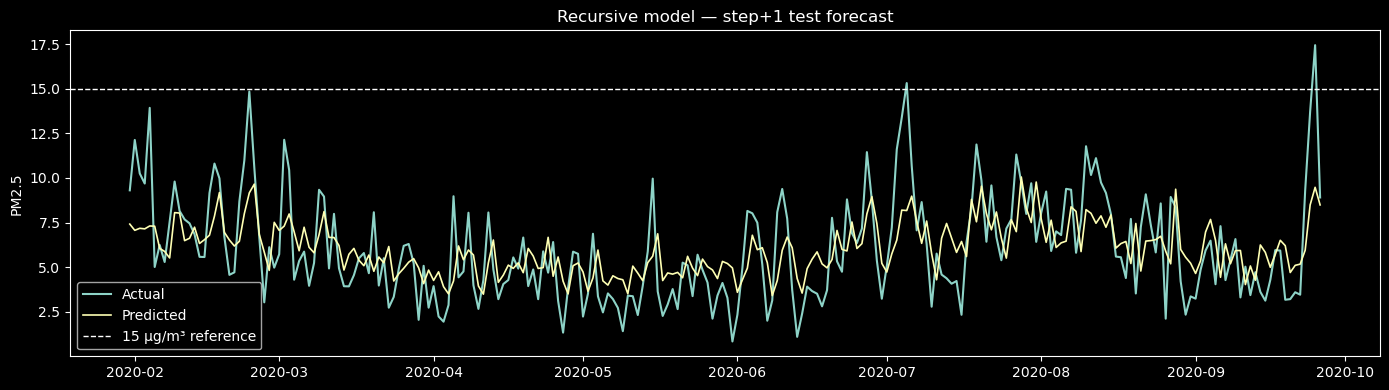

In [23]:
# Plot first recursive step and full 7-step average behavior.
y_true_step1 = inverse_feature_target_scaled(y_test_dyn_r[:, 0, target_dynamic_pos])
y_pred_step1 = inverse_feature_target_scaled(pred_test_dyn_r[:, 0, target_dynamic_pos])
first_dates = [d[0] for d in test_ds_r.target_dates]

best_recursive_step1_metrics = regression_metrics(y_true_step1, y_pred_step1, label="Recursive model step+1")
print_metrics(best_recursive_step1_metrics)
plot_forecast_series(first_dates, y_true_step1, y_pred_step1, "Recursive model — step+1 test forecast", n=240)

# Save final recursive model.
torch.save(best_recursive_model.state_dict(), OUT_DIR / "best_recursive_7day_point.pt")
with open(OUT_DIR / "best_recursive_7day_config.json", "w") as f:
    json.dump(best_recursive_cfg, f, indent=2)


## Section 20 — Tube Loss variant

Tube Loss / ε-insensitive loss:

\[
L(y, \hat y) = \max(0, |y - \hat y| - \epsilon)
\]

It ignores errors smaller than \(\epsilon\). This can make forecasts smoother, but may also hide small but systematic bias. We test it as a variant because it was requested.


In [24]:
TUBE_GRID = []
base_cfg = best_recursive_cfg.copy() if best_recursive_cfg is not None else {
    "rnn_type": "GRU", "lookback": DEFAULT_LOOKBACK, "hidden_size": 128, "num_layers": 1,
    "dropout": 0.1, "lr": 5e-4, "target_weight": 3.0, "aux_weight": 1.0, "weight_decay": 1e-4
}
for eps in [0.02, 0.05, 0.10]:
    cfg = base_cfg.copy()
    cfg["base_loss"] = "tube"
    cfg["tube_eps"] = eps
    TUBE_GRID.append(cfg)

if FAST_DEV_RUN:
    TUBE_GRID = TUBE_GRID[:1]

print("Tube configs:", TUBE_GRID)


Tube configs: [{'rnn_type': 'GRU', 'lookback': 30, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.0005, 'target_weight': 3.0, 'aux_weight': 1.0, 'weight_decay': 0.0001, 'base_loss': 'tube', 'tube_eps': 0.02}, {'rnn_type': 'GRU', 'lookback': 30, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.0005, 'target_weight': 3.0, 'aux_weight': 1.0, 'weight_decay': 0.0001, 'base_loss': 'tube', 'tube_eps': 0.05}, {'rnn_type': 'GRU', 'lookback': 30, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.0005, 'target_weight': 3.0, 'aux_weight': 1.0, 'weight_decay': 0.0001, 'base_loss': 'tube', 'tube_eps': 0.1}]


In [25]:
tube_results = []
best_tube = {"val_R2_step1": -np.inf, "model": None, "cfg": None, "history": None, "datasets": None}

for i, cfg in enumerate(TUBE_GRID, 1):
    print(f"\nTube [{i}/{len(TUBE_GRID)}] {cfg}")
    train_ds, val_ds, test_ds, train_loader, val_loader, test_loader = make_recursive_loaders(
        lookback=cfg["lookback"], rollout=RECURSIVE_ROLLOUT
    )
    model = RecursivePointForecaster(
        input_size=len(SEQ_FEATURE_COLS),
        dynamic_size=len(DYNAMIC_COLS),
        rnn_type=cfg["rnn_type"],
        hidden_size=cfg["hidden_size"],
        num_layers=cfg["num_layers"],
        dropout=cfg["dropout"],
    )
    model, hist, best_val_loss = train_recursive_point_model(
        model, train_loader, val_loader,
        lr=cfg["lr"], weight_decay=cfg["weight_decay"],
        target_weight=cfg["target_weight"], aux_weight=cfg["aux_weight"],
        base_loss="tube", tube_eps=cfg["tube_eps"], verbose=False,
    )
    y_val_dyn, pred_val_dyn = predict_recursive_point(model, val_loader)
    step_df = recursive_step_metrics(y_val_dyn, pred_val_dyn, label_prefix="tube val")
    row = {**cfg, "best_val_loss": best_val_loss, "val_R2_step1": step_df.loc[0, "R2"], "val_R2_mean7": step_df["R2"].mean()}
    tube_results.append(row)
    print(f"Val step+1 R2={row['val_R2_step1']:.4f} | mean7={row['val_R2_mean7']:.4f}")

    if row["val_R2_step1"] > best_tube["val_R2_step1"]:
        best_tube.update({"val_R2_step1": row["val_R2_step1"], "model": model, "cfg": cfg, "history": hist,
                          "datasets": (train_ds, val_ds, test_ds, train_loader, val_loader, test_loader)})

tube_results_df = pd.DataFrame(tube_results).sort_values("val_R2_step1", ascending=False)
tube_results_df



Tube [1/3] {'rnn_type': 'GRU', 'lookback': 30, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.0005, 'target_weight': 3.0, 'aux_weight': 1.0, 'weight_decay': 0.0001, 'base_loss': 'tube', 'tube_eps': 0.02}
Val step+1 R2=0.3216 | mean7=0.1176

Tube [2/3] {'rnn_type': 'GRU', 'lookback': 30, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.0005, 'target_weight': 3.0, 'aux_weight': 1.0, 'weight_decay': 0.0001, 'base_loss': 'tube', 'tube_eps': 0.05}
Val step+1 R2=0.3414 | mean7=0.1283

Tube [3/3] {'rnn_type': 'GRU', 'lookback': 30, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.0005, 'target_weight': 3.0, 'aux_weight': 1.0, 'weight_decay': 0.0001, 'base_loss': 'tube', 'tube_eps': 0.1}
Val step+1 R2=0.3299 | mean7=0.1165


,rnn_type,lookback,hidden_size,num_layers,dropout,lr,target_weight,aux_weight,weight_decay,base_loss,tube_eps,best_val_loss,val_R2_step1,val_R2_mean7
1,GRU,30,64,1,0.2,0.0005,3.0,1.0,0.0001,tube,0.05,2.187512,0.341413,0.128332
2,GRU,30,64,1,0.2,0.0005,3.0,1.0,0.0001,tube,0.10,1.983821,0.329927,0.116547
0,GRU,30,64,1,0.2,0.0005,3.0,1.0,0.0001,tube,0.02,2.278960,0.321583,0.117620


In [26]:
if best_tube["model"] is not None:
    train_ds_t, val_ds_t, test_ds_t, train_loader_t, val_loader_t, test_loader_t = best_tube["datasets"]
    y_test_dyn_t, pred_test_dyn_t = predict_recursive_point(best_tube["model"], test_loader_t)
    tube_test_steps_df = recursive_step_metrics(y_test_dyn_t, pred_test_dyn_t, label_prefix="Tube recursive test")
    display(tube_test_steps_df)

    y_true_tube_step1 = inverse_feature_target_scaled(y_test_dyn_t[:, 0, target_dynamic_pos])
    y_pred_tube_step1 = inverse_feature_target_scaled(pred_test_dyn_t[:, 0, target_dynamic_pos])
    best_tube_step1_metrics = regression_metrics(y_true_tube_step1, y_pred_tube_step1, label="Tube recursive step+1")
    print_metrics(best_tube_step1_metrics)

    torch.save(best_tube["model"].state_dict(), OUT_DIR / "best_recursive_7day_tube.pt")
    with open(OUT_DIR / "best_recursive_7day_tube_config.json", "w") as f:
        json.dump(best_tube["cfg"], f, indent=2)
else:
    tube_test_steps_df = pd.DataFrame()
    best_tube_step1_metrics = None


,model,MAE,RMSE,R2
0,Tube recursive test step+1,2.163674,3.438358,0.290156
1,Tube recursive test step+2,2.568378,3.941531,0.066813
2,Tube recursive test step+3,2.615378,3.997030,0.038342
3,Tube recursive test step+4,2.597767,4.005289,0.034580
4,Tube recursive test step+5,2.575294,4.000911,0.039777
5,Tube recursive test step+6,2.561831,4.000208,0.044394
6,Tube recursive test step+7,2.556935,3.999487,0.047255


Tube recursive step+1: MAE=2.1637, RMSE=3.4384, R2=0.2902


## Section 21 — Recursive quantile model

This model outputs:

- Point predictions for all dynamic variables, so the recursion can continue.
- Quantiles for PM2.5, so we can evaluate uncertainty intervals.

For feedback into the recursive window, the PM2.5 value is replaced by the **median quantile**. This is safer than feeding a random upper/lower quantile into the future state.


In [27]:
class RecursiveQuantileForecaster(nn.Module):
    def __init__(self, input_size, dynamic_size, n_quantiles, rnn_type="GRU", hidden_size=128, num_layers=1, dropout=0.1):
        super().__init__()
        self.dynamic_size = dynamic_size
        self.n_quantiles = n_quantiles
        self.backbone = RecurrentRegressor(
            input_size=input_size,
            rnn_type=rnn_type,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            output_size=dynamic_size + n_quantiles,
        )

    def forward(self, x):
        out = self.backbone(x)
        dyn = out[:, :self.dynamic_size]
        q = out[:, self.dynamic_size:]
        q = torch.sort(q, dim=1).values
        return dyn, q


def recursive_quantile_rollout(model, x_hist, future_known):
    window = x_hist
    dyn_preds = []
    q_preds = []
    rollout = future_known.shape[1]
    for step in range(rollout):
        pred_dyn, pred_q = model(window)
        # Feed back median quantile as PM2.5 dynamic value.
        pred_dyn_feedback = pred_dyn.clone()
        pred_dyn_feedback[:, target_dynamic_pos] = pred_q[:, MEDIAN_Q_INDEX]
        dyn_preds.append(pred_dyn_feedback.unsqueeze(1))
        q_preds.append(pred_q.unsqueeze(1))
        next_row = build_next_row(pred_dyn_feedback, future_known[:, step, :])
        window = torch.cat([window[:, 1:, :], next_row.unsqueeze(1)], dim=1)
    return torch.cat(dyn_preds, dim=1), torch.cat(q_preds, dim=1)


def recursive_quantile_loss(pred_dyn, pred_q, true_dyn, target_weight=2.0, aux_weight=0.5):
    true_target = true_dyn[:, :, target_dynamic_pos]  # (B, R)
    # Pinball over all steps and quantiles.
    q = torch.tensor(QUANTILES, device=pred_q.device, dtype=pred_q.dtype).view(1, 1, -1)
    err = true_target.unsqueeze(-1) - pred_q
    q_loss = torch.maximum(q * err, (q - 1) * err).mean()
    aux = nn.functional.smooth_l1_loss(pred_dyn, true_dyn, beta=0.5)
    return target_weight * q_loss + aux_weight * aux


In [28]:
def train_recursive_quantile_model(model, train_loader, val_loader, lr=5e-4, weight_decay=1e-4,
                                   max_epochs=MAX_EPOCHS, patience=PATIENCE,
                                   target_weight=2.0, aux_weight=0.5, verbose=False):
    model = model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    best_state = None
    best_val = float("inf")
    wait = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_losses = []
        for x_hist, future_known, y_dyn in train_loader:
            x_hist = x_hist.to(DEVICE)
            future_known = future_known.to(DEVICE)
            y_dyn = y_dyn.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            pred_dyn, pred_q = recursive_quantile_rollout(model, x_hist, future_known)
            loss = recursive_quantile_loss(pred_dyn, pred_q, y_dyn, target_weight=target_weight, aux_weight=aux_weight)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for x_hist, future_known, y_dyn in val_loader:
                x_hist = x_hist.to(DEVICE)
                future_known = future_known.to(DEVICE)
                y_dyn = y_dyn.to(DEVICE)
                pred_dyn, pred_q = recursive_quantile_rollout(model, x_hist, future_known)
                loss = recursive_quantile_loss(pred_dyn, pred_q, y_dyn, target_weight=target_weight, aux_weight=aux_weight)
                val_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))
        val_loss = float(np.mean(val_losses))
        history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})
        if verbose and (epoch == 1 or epoch % 10 == 0):
            print(f"Epoch {epoch:03d} | train={train_loss:.5f} | val={val_loss:.5f}")

        if val_loss < best_val - MIN_DELTA:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, pd.DataFrame(history), best_val


def predict_recursive_quantile(model, loader):
    model.eval()
    dyn_preds = []
    q_preds = []
    actuals = []
    with torch.no_grad():
        for x_hist, future_known, y_dyn in loader:
            x_hist = x_hist.to(DEVICE)
            future_known = future_known.to(DEVICE)
            pred_dyn, pred_q = recursive_quantile_rollout(model, x_hist, future_known)
            dyn_preds.append(pred_dyn.cpu().numpy())
            q_preds.append(pred_q.cpu().numpy())
            actuals.append(y_dyn.numpy())
    return np.concatenate(actuals, axis=0), np.concatenate(dyn_preds, axis=0), np.concatenate(q_preds, axis=0)


## Section 22 — Train/evaluate recursive quantile model


In [29]:
q_base = best_recursive_cfg.copy() if best_recursive_cfg is not None else {
    "rnn_type": "GRU", "lookback": DEFAULT_LOOKBACK, "hidden_size": 128, "num_layers": 1,
    "dropout": 0.1, "lr": 5e-4, "weight_decay": 1e-4,
}

train_ds_rq, val_ds_rq, test_ds_rq, train_loader_rq, val_loader_rq, test_loader_rq = make_recursive_loaders(
    lookback=q_base["lookback"], rollout=RECURSIVE_ROLLOUT
)

recursive_q_model = RecursiveQuantileForecaster(
    input_size=len(SEQ_FEATURE_COLS),
    dynamic_size=len(DYNAMIC_COLS),
    n_quantiles=len(QUANTILES),
    rnn_type=q_base.get("rnn_type", "GRU"),
    hidden_size=q_base.get("hidden_size", 128),
    num_layers=q_base.get("num_layers", 1),
    dropout=q_base.get("dropout", 0.1),
)

recursive_q_model, recursive_q_hist, recursive_q_val_loss = train_recursive_quantile_model(
    recursive_q_model, train_loader_rq, val_loader_rq,
    lr=q_base.get("lr", 5e-4), weight_decay=q_base.get("weight_decay", 1e-4),
    verbose=True,
)

# Test evaluation
true_dyn_q, pred_dyn_q, pred_quantiles_scaled = predict_recursive_quantile(recursive_q_model, test_loader_rq)

# Median metrics per step
median_scaled = pred_quantiles_scaled[:, :, MEDIAN_Q_INDEX]
rows = []
for step in range(RECURSIVE_ROLLOUT):
    y_true_pm25 = inverse_feature_target_scaled(true_dyn_q[:, step, target_dynamic_pos])
    y_pred_pm25 = inverse_feature_target_scaled(median_scaled[:, step])
    rows.append(regression_metrics(y_true_pm25, y_pred_pm25, label=f"Recursive quantile median step+{step+1}"))
recursive_quantile_steps_df = pd.DataFrame(rows)
recursive_quantile_steps_df


Epoch 001 | train=0.84682 | val=0.68571
Epoch 010 | train=0.60663 | val=0.54568
Epoch 020 | train=0.59053 | val=0.53297
Epoch 030 | train=0.58229 | val=0.54134


,model,MAE,RMSE,R2
0,Recursive quantile median step+1,2.337177,3.684672,0.184811
1,Recursive quantile median step+2,2.613305,4.057704,0.010993
2,Recursive quantile median step+3,2.648080,4.115428,-0.019473
3,Recursive quantile median step+4,2.646540,4.134953,-0.028939
4,Recursive quantile median step+5,2.640690,4.145539,-0.030899
5,Recursive quantile median step+6,2.635598,4.154162,-0.030577
6,Recursive quantile median step+7,2.635999,4.159417,-0.030464



Recursive quantile step+1
50% PI: PICP=0.3928, MPIW=2.9492
80% PI: PICP=0.8043, MPIW=7.2085
90% PI: PICP=0.8950, MPIW=9.4802

Recursive quantile step+7
50% PI: PICP=0.3755, MPIW=2.9682
80% PI: PICP=0.7612, MPIW=6.7911
90% PI: PICP=0.8590, MPIW=9.2410


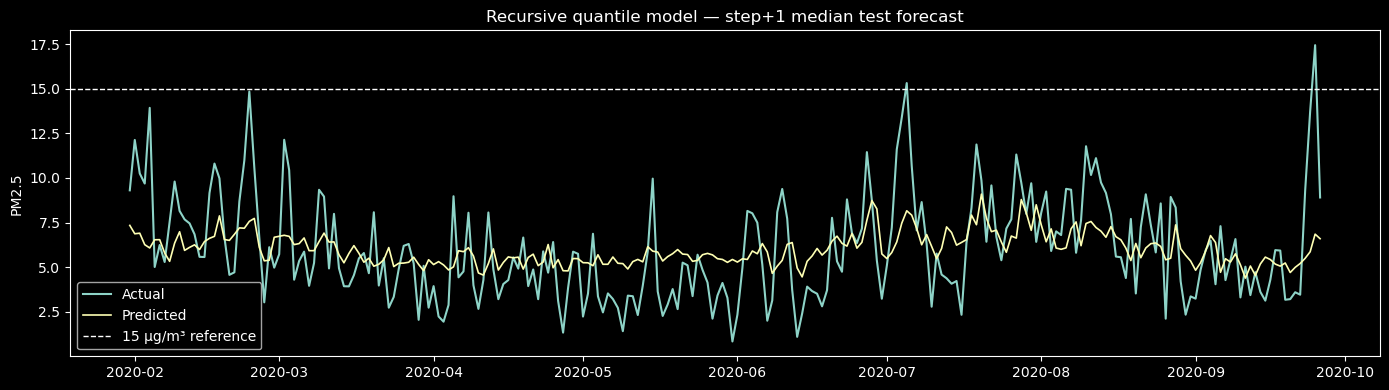

In [30]:
# Interval metrics for step+1 and step+7.
for step in [0, RECURSIVE_ROLLOUT - 1]:
    y_true_pm25 = inverse_feature_target_scaled(true_dyn_q[:, step, target_dynamic_pos])
    q_orig = np.column_stack([
        inverse_feature_target_scaled(pred_quantiles_scaled[:, step, j])
        for j in range(len(QUANTILES))
    ])
    print(f"\nRecursive quantile step+{step+1}")
    for low_q, high_q, nominal in [(0.25, 0.75, 0.50), (0.10, 0.90, 0.80), (0.05, 0.95, 0.90)]:
        lo = q_orig[:, QUANTILES.index(low_q)]
        hi = q_orig[:, QUANTILES.index(high_q)]
        picp, mpiw = picp_mpiw(y_true_pm25, lo, hi)
        print(f"{int(nominal*100)}% PI: PICP={picp:.4f}, MPIW={mpiw:.4f}")

# Plot step+1 recursive quantile median.
y_true_q_step1 = inverse_feature_target_scaled(true_dyn_q[:, 0, target_dynamic_pos])
y_med_q_step1 = inverse_feature_target_scaled(median_scaled[:, 0])
plot_forecast_series([d[0] for d in test_ds_rq.target_dates], y_true_q_step1, y_med_q_step1,
                     "Recursive quantile model — step+1 median test forecast", n=240)

torch.save(recursive_q_model.state_dict(), OUT_DIR / "best_recursive_7day_quantile.pt")
with open(OUT_DIR / "best_recursive_7day_quantile_config.json", "w") as f:
    json.dump(q_base, f, indent=2)


# Part D — Final comparison, model selection, and next-7-day inference


## Section 23 — Final comparison table

The key rows to inspect are:

- Improved direct 1-day point model
- Improved direct 1-day quantile median
- Recursive model step+1
- Recursive model average across 7 rollout steps
- Tube recursive model, if it improves validation/test performance


In [31]:
comparison_rows = []
comparison_rows.append({"Model": "Previous ARMA(2,1)", "Scope": "old statistical", "MAE": np.nan, "RMSE": np.nan, "R2": 0.311})
comparison_rows.append({"Model": "Previous best quantile GRU median", "Scope": "old DL 1-day", "MAE": np.nan, "RMSE": np.nan, "R2": 0.400})
comparison_rows.append({"Model": best_1day_point_metrics["model"], "Scope": "new direct 1-day", "MAE": best_1day_point_metrics["MAE"], "RMSE": best_1day_point_metrics["RMSE"], "R2": best_1day_point_metrics["R2"]})
comparison_rows.append({"Model": best_1day_quantile_metrics["model"], "Scope": "new direct 1-day quantile", "MAE": best_1day_quantile_metrics["MAE"], "RMSE": best_1day_quantile_metrics["RMSE"], "R2": best_1day_quantile_metrics["R2"]})
comparison_rows.append({"Model": best_recursive_step1_metrics["model"], "Scope": "new recursive step+1", "MAE": best_recursive_step1_metrics["MAE"], "RMSE": best_recursive_step1_metrics["RMSE"], "R2": best_recursive_step1_metrics["R2"]})

if hgb_test_metrics is not None:
    comparison_rows.append({"Model": hgb_test_metrics["model"], "Scope": "diagnostic tabular 1-day", "MAE": hgb_test_metrics["MAE"], "RMSE": hgb_test_metrics["RMSE"], "R2": hgb_test_metrics["R2"]})

if best_tube_step1_metrics is not None:
    comparison_rows.append({"Model": best_tube_step1_metrics["model"], "Scope": "tube recursive step+1", "MAE": best_tube_step1_metrics["MAE"], "RMSE": best_tube_step1_metrics["RMSE"], "R2": best_tube_step1_metrics["R2"]})

# Recursive 7-step mean metrics.
comparison_rows.append({
    "Model": "Recursive GRU mean over 7 rollout steps",
    "Scope": "new recursive 7-day",
    "MAE": recursive_test_steps_df["MAE"].mean(),
    "RMSE": recursive_test_steps_df["RMSE"].mean(),
    "R2": recursive_test_steps_df["R2"].mean(),
})
comparison_rows.append({
    "Model": "Recursive quantile median mean over 7 steps",
    "Scope": "new recursive quantile 7-day",
    "MAE": recursive_quantile_steps_df["MAE"].mean(),
    "RMSE": recursive_quantile_steps_df["RMSE"].mean(),
    "R2": recursive_quantile_steps_df["R2"].mean(),
})

comparison_df = pd.DataFrame(comparison_rows).sort_values("R2", ascending=False)
comparison_df


NameError: name 'best_1day_point_metrics' is not defined

In [32]:
plt.figure(figsize=(11, 5))
plot_df = comparison_df.dropna(subset=["R2"]).copy()
plt.barh(plot_df["Model"], plot_df["R2"])
plt.axvline(0.311, linestyle="--", linewidth=1, label="Old statistical ceiling: ARMA R²≈0.311")
plt.axvline(0.400, linestyle=":", linewidth=1, label="Old best DL R²≈0.40")
plt.axvline(0.600, linestyle="-.", linewidth=1, label="Target R²=0.60")
plt.xlabel("Test R²")
plt.title("Old vs new PM2.5 forecasting results")
plt.legend()
plt.tight_layout()
plt.show()


NameError: name 'comparison_df' is not defined

<Figure size 1100x500 with 0 Axes>

## Section 24 — Next-7-days recursive inference after the last available date

This cell demonstrates how to forecast beyond the dataset. Future calendar variables are known. Future Temperature/Wind/RH/PM2.5 are recursively predicted by the model.


In [33]:
def make_future_known_scaled(last_date, periods):
    future_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=periods, freq="D")
    dummy = pd.DataFrame(index=future_dates)
    # Fill dynamic columns with train means before scaling; they will not be used from known_indices.
    for col in [TARGET_COL, TEMP_COL, WIND_COL, RH_COL]:
        if col == TARGET_COL:
            dummy[col] = train_raw[TARGET_COL].median()
        else:
            dummy[col] = train_raw[col].median()
    dummy = add_time_features(dummy)
    if ALLOW_AQI_AS_FEATURE and "AQI_log" in SEQ_FEATURE_COLS:
        dummy["AQI_log"] = 0.0
    full_scaled = transform_features(dummy)
    known_scaled = full_scaled[:, known_indices]
    return future_dates, torch.tensor(known_scaled, dtype=torch.float32).unsqueeze(0).to(DEVICE)

best_recursive_model.eval()
last_window_np = transform_features(df_feat.iloc[-best_recursive_cfg["lookback"]:])
last_window = torch.tensor(last_window_np, dtype=torch.float32).unsqueeze(0).to(DEVICE)
future_dates, future_known = make_future_known_scaled(df_feat.index[-1], RECURSIVE_ROLLOUT)

with torch.no_grad():
    future_pred_dyn = recursive_point_rollout(best_recursive_model.to(DEVICE), last_window, future_known).cpu().numpy()[0]

future_pm25 = inverse_feature_target_scaled(future_pred_dyn[:, target_dynamic_pos])
future_forecast_df = pd.DataFrame({"Date": future_dates, "Predicted_PM2.5": future_pm25})
future_forecast_df


,Date,Predicted_PM2.5
0,2022-01-01,6.776972
1,2022-01-02,8.745907
2,2022-01-03,10.518305
3,2022-01-04,11.324992
4,2022-01-05,11.424562
5,2022-01-06,11.841804
6,2022-01-07,12.077367


## Section 25 — How to interpret results

Use this logic after running the notebook:

1. **If improved 1-day direct GRU/LSTM reaches near 0.60 R²**, use it as your strongest 1-day model.
2. **If recursive step+1 is lower than direct step+1**, that is expected because the recursive model has a harder task: it predicts PM2.5 and weather variables together.
3. **If recursive 7-day R² degrades sharply from step+1 to step+7**, that confirms error accumulation.
4. **If Tube Loss is worse**, report that it was tested but not selected because it reduced R²/calibration.
5. **If the tabular model beats all neural models**, explain that the dataset has strong lag/rolling structure and tree boosting captures it efficiently; still keep GRU/LSTM as the required sequence models.
6. **If R² still stays below 0.60**, the likely causes are missing predictors such as pressure, dew point, precipitation, wind direction, boundary-layer height, emissions/traffic, wildfire/smoke indicators, or monitoring-site changes.


## Section 26 — Slide/report text you can use

**Improved 1-day forecasting:**  
The earlier deep-learning models reached about R² ≈ 0.40, with the best result coming from the 1-horizon quantile GRU median forecast. To explicitly improve the 1-day task, we retuned GRU/LSTM architectures over lookback window, hidden size, number of layers, dropout, and learning rate. The target was modelled in log1p space to reduce the influence of PM2.5 spikes, and evaluation was performed after inverse transformation to original µg/m³ units.

**Recursive 7-day forecasting:**  
Instead of predicting all 7 days at once, the new recursive model predicts the complete next-day dynamic state: PM2.5, temperature, wind speed, and relative humidity. The predicted state is appended to the window and reused to predict the following day. Training uses a 7-step rollout loss, allowing gradients to flow through the recursive chain in a BPTT-style manner. This directly penalises the accumulated forecast error across the 7-day horizon.

**Tube Loss variant:**  
A Tube Loss variant was tested by ignoring errors within an ε-margin. This was compared against the Huber/Pinball objectives. The final selection should be based on validation/test R² for point forecasts and PICP/MPIW for quantile forecasts.
